# Tail Kinematics - RNN approach

RoboSalmon has a segmented tail, ech one controlled by a DC motor. The resultant position of each segment is calculated using a Denavit-Hartenberg respresentation.
While this representation have 4 parameters, only the link lenght a, and the joint angle \theta are relevant given the tail construction.

For this Task the input features are the angular positions of each motor (x8) in degrees

The output are the x,y coordinates of each motor with respect to the body frame in meters.

In [1]:
import numpy as np  
import matplotlib.pyplot as plt  
from sklearn.preprocessing import MinMaxScaler  
from sklearn.model_selection import train_test_split 
import torch  
import torch.nn as nn  
import torch.optim as optim 

In [2]:
import nn_fncs
import numpy as np
import scipy.io


mat_data= scipy.io.loadmat('Data/kinematics_data2.mat', )
data_input = mat_data.get('nn_input')[:,:8]
data_output = mat_data.get('nn_output')
data_input = np.expand_dims(data_input, axis=2)
data_output = np.concatenate((data_output[:,1:9],data_output[:,10:18]), axis=1)
print("Input and output data shapes:")
print(data_input.shape)
print(data_output.shape)


Input and output data shapes:
(500000, 8, 1)
(500000, 16)


In [3]:
def point_distances_from_sample(sample):
    """
    Calculate Euclidean distances between paired (x, y) coordinates in a sample.
    Pairs: (0,8), (1,9), ..., (7,15)
    Args:
        sample (np.ndarray): 1D array with 16 elements, first 8 are x, next 8 are y.
    Returns:
        np.ndarray: Array of distances for each pair.
    """
    x_coords = sample[:8]
    y_coords = sample[8:16]
    distances = np.sqrt((x_coords[1:] - x_coords[:-1])**2 + (y_coords[1:] - y_coords[:-1])**2)  # Distance from origin
    return distances


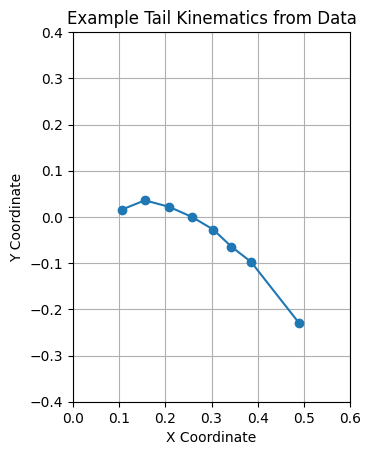

In [4]:
import matplotlib.pyplot as plt
import random

def plot_tail(sample, title="Tail Kinematics"):
    """
    Plot the tail kinematics given a sample of 16 values (8 x-coordinates and 8 y-coordinates).
    Args:
        sample (np.ndarray): 1D array with 16 elements, first 8 are x, next 8 are y.
        title (str): Title of the plot.
    """
    x_coords = sample[:8]
    y_coords = sample[8:16]
    
    plt.plot(x_coords, y_coords, marker='o')
    plt.xlim(0, 0.6)
    plt.ylim(-0.4, 0.4)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.title(title)
    plt.grid()
    plt.gca().set_aspect('equal')


# Example usage
# Randomly select a sample from data_output and plot
random_index = random.randint(0, data_output.shape[0] - 1)
plot_tail(data_output[random_index], title="Example Tail Kinematics from Data")



In [5]:
# Dataset preparation

import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F

torch.set_default_dtype(torch.float64)
# Normalize data
# data_input = F.normalize(torch.tensor(data_input, dtype=torch.float64))
# data_output = F.normalize(torch.tensor(data_output, dtype=torch.float64))
# Define dataset split percentages
train_data_percentage = 0.85
valid_data_percentage = 0.1
test_data_percentage = 0.05

train_size = int(len(data_input) * train_data_percentage)
valid_size = int(len(data_input) * valid_data_percentage)
test_size = len(data_input) - train_size - valid_size

valid_index_start = train_size
valid_index_end = train_size + valid_size
test_index_start = valid_index_end
test_index_end = len(data_input) 
#

# Split data into training and validation sets
train_dataset = torch.utils.data.TensorDataset(torch.tensor(data_input[:train_size], dtype=torch.float64), 
                                               torch.tensor(data_output[:train_size], dtype=torch.float64))
valid_dataset = torch.utils.data.TensorDataset(torch.tensor(data_input[valid_index_start:valid_index_end], dtype=torch.float64), 
                                               torch.tensor(data_output[valid_index_start:valid_index_end], dtype=torch.float64))
# valid_dataset_input = torch.tensor(data_input[valid_index_start:valid_index_end], dtype=torch.float64)
# valid_dataset_output = torch.tensor(data_output[valid_index_start:valid_index_end], dtype=torch.float64)
#Test dataset
test_dataset_input = torch.tensor(data_input[test_index_start:test_index_end], dtype=torch.float64)
test_dataset_output = torch.tensor(data_output[test_index_start:test_index_end], dtype=torch.float64)
# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=100, shuffle=True)

test_dataset_output.dtype

print(f'Train dataset size: {len(train_dataset)}')
print(f'Validation dataset size: {len(valid_dataset)}')
print(f'Test dataset size: {len(test_dataset_input)}')

Train dataset size: 425000
Validation dataset size: 50000
Test dataset size: 25000


In [6]:
print(f'Test dataset input shape: {test_dataset_input.shape}')
print(f'Test dataset output shape: {test_dataset_output.shape}')

Test dataset input shape: torch.Size([25000, 8, 1])
Test dataset output shape: torch.Size([25000, 16])


In [7]:
# MODEL STRUCTURE

import torch
import torch.nn as nn
import torch.nn.functional as F

class TailKinematicsRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=2, num_layers=8, output_size=16):  
        super(TailKinematicsRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(hidden_size*num_layers, output_size)
        
    def forward(self, x):
        
        out, _ = self.rnn(x)
        out = self.flatten(out)
        out = self.fc(out)  # Get the output of the
        
        return out

# Create the model
model = TailKinematicsRNN()

# Print model summary
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {total_params}")

TailKinematicsRNN(
  (rnn): RNN(1, 2, num_layers=8, batch_first=True)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=16, out_features=16, bias=True)
)
Number of parameters: 366


In [8]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
criterion = nn.MSELoss()
# Get one batch from train_loader
input_data, output_data = next(iter(train_loader))
# Move data to GPU if available
input_data, output_data = input_data.to(device), output_data.to(device)
model = model.to(device)
with torch.set_grad_enabled(True):
    # Forward pass
    pred = model(input_data)
    loss = criterion(pred, output_data)

In [30]:
# Training loop
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import torch
from torcheval.metrics.functional import mean_squared_error, r2_score
import math

def train_model(model, criterion, optimizer, best_model_file_name, num_epochs=30):
    best_accuracy = 0.0
    # Select the available device
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    model = model.to(device)
    hist_train_loss = np.zeros((num_epochs,1))
    hist_valid_loss = np.zeros((num_epochs,1))    

    hist_train_r2 = np.zeros((num_epochs,1))
    hist_valid_r2 = np.zeros((num_epochs,1))
    # Training loop
    with tqdm(total=100) as pbar:
        for epoch in range(num_epochs):
            
            model.train()
            running_loss = 0.0
            running_r2 = 0.0
            running_mse = 0.0
            for input_data, output_data in train_loader:
                # Move data to GPU if available
                input_data, output_data = input_data.to(device), output_data.to(device)
                with torch.set_grad_enabled(True):
                    # Forward pass
                    pred = model(input_data)
                    #loss = my_custom_loss(pred, output_data)
                    loss = criterion(pred, output_data)
                    # Backward and optimize
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
                # Batch loss and correct predictions
                running_loss += loss.item() * input_data.shape[0] # Multiply for batch size
                running_r2 += r2_score(pred, output_data).item() * input_data.shape[0]
                running_mse += mean_squared_error(pred,output_data).item()* input_data.shape[0]

            # Epoch loss and accuracy
            epoch_loss = running_loss / len(train_dataset)
            r2 = running_r2 / len(train_dataset)
            mse = running_mse / len(train_dataset)
            if (epoch+1) % (num_epochs/10) == 0:
                print(f"Epoch [{epoch+1}/{num_epochs}]:")
                print(f"Train loss: {epoch_loss:1.5E} -- R2: {r2:1.5E} -- MSE: {mse:1.5E} ")
            
            hist_train_loss[epoch] = epoch_loss
            hist_train_r2[epoch] = r2
            
            # Evaluation
            running_loss = 0.0
            running_r2 = 0.0
            running_mse = 0.0
            
            model.eval()
            for input_data, output_data in valid_loader:
                # Move data to GPU if available
                input_data, output_data = input_data.to(device), output_data.to(device)
                with torch.no_grad():
                    pred = model(input_data)
                    #loss = my_custom_loss(pred, output_data)
                    loss = criterion(pred, output_data)
                    running_loss += loss.item()
                # Batch loss and correct predictions
                running_loss += loss.item() * input_data.shape[0] # Multiply for batch size
                running_r2 += r2_score(pred, output_data).item() * input_data.shape[0]
                running_mse += mean_squared_error(pred,output_data)* input_data.shape[0]
            # Epoch loss and accuracy
            epoch_loss = running_loss / len(valid_dataset)
            r2 = running_r2 / len(valid_dataset)
            mse = running_mse / len(valid_dataset)
            
            if (epoch+1) % (num_epochs/10) == 0:
                print(f"Valid loss: {epoch_loss:1.5E} -- R2: {r2:1.5E} -- MSE: {mse:1.5E} ")
                print(60*"=")
                pbar.update(10)
            if r2 > best_accuracy:
                    best_accuracy = r2
                    # Save the model only if its better than the one already saved
                    nn_fncs.save_best_model(model, best_accuracy, 0.9 ,model_name=best_model_file_name)
            
            hist_valid_loss[epoch] = epoch_loss
            hist_valid_r2[epoch] = r2
    plt.plot(hist_train_loss, label='Train Loss')
    plt.plot(hist_valid_loss, label='Valid Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    plt.plot(hist_train_r2, label='Train R2')
    plt.plot(hist_valid_r2, label='Valid R2')
    plt.xlabel('Epoch')
    plt.ylabel('R2')
    plt.legend()
    plt.show()

    print(f"Best validation accuracy: {best_accuracy}")
    return model

Using device: cuda:0


  0%|          | 0/100 [00:00<?, ?it/s]

Epoch [5/50]:
Train loss: 6.83934E-04 -- R2: 8.91974E-01 -- MSE: 6.83934E-04 


 10%|█         | 10/100 [03:42<33:22, 22.25s/it]

Valid loss: 7.00428E-04 -- R2: 8.95467E-01 -- MSE: 6.93493E-04 
New best model saved: best_model_rnn_0.9035628692.pt (Accuracy: 0.9035628692)
New best model saved: best_model_rnn_0.9079266165.pt (Accuracy: 0.9079266165)
New best model saved: best_model_rnn_0.9134837102.pt (Accuracy: 0.9134837102)
Epoch [10/50]:
Train loss: 4.93371E-04 -- R2: 9.19733E-01 -- MSE: 4.93371E-04 


...

Valid loss: 9.97160E-05 -- R2: 9.79993E-01 -- MSE: 9.87287E-05 
Epoch [45/50]:
Train loss: 9.81952E-05 -- R2: 9.77469E-01 -- MSE: 9.81952E-05 


 90%|█████████ | 90/100 [35:41<03:58, 23.85s/it]

Valid loss: 9.41524E-05 -- R2: 9.79802E-01 -- MSE: 9.32202E-05 
Epoch [50/50]:
Train loss: 9.39373E-05 -- R2: 9.76542E-01 -- MSE: 9.39373E-05 


100%|██████████| 100/100 [39:33<00:00, 23.74s/it]

Valid loss: 9.40923E-05 -- R2: 9.78624E-01 -- MSE: 9.31607E-05 


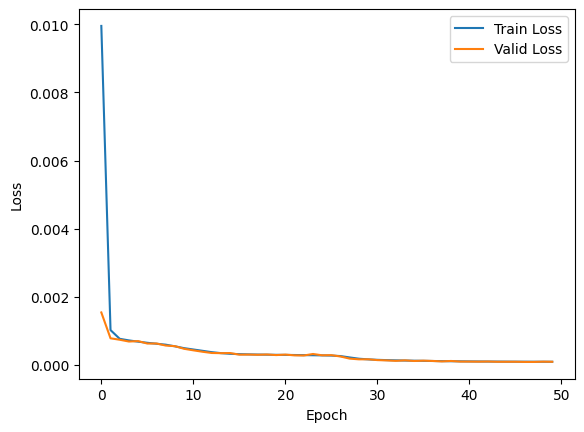

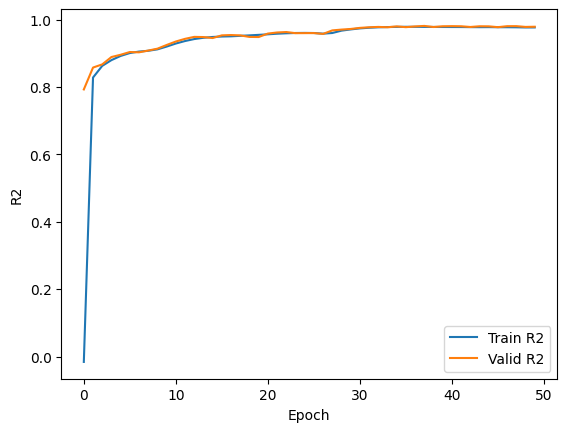

Best validation accuracy: 0.9810397131122237


In [34]:
# TRAINING 

model = TailKinematicsRNN()
# Hyperparameters
learning_rate = 1e-3
num_epochs = 50

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

model = train_model(model, criterion, optimizer, best_model_file_name= 'best_model_rnn', num_epochs = num_epochs)

In [11]:
# TESTING
import torch
from torcheval.metrics.functional import mean_squared_error, r2_score
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# Load the best model
import nn_fncs
model = TailKinematicsRNN()
model_path = nn_fncs.best_model_path('./BestModel/', model_name='best_model_rnn')
model.load_state_dict(torch.load('./BestModel/' + model_path))
model = model.to(device)

#evaluate the model
model.eval()
print(f"Using device: {device}")
test_dataset_input = test_dataset_input.to(device)
test_dataset_output = test_dataset_output.to(device)
pred = model(test_dataset_input)

mean_squared_error(pred,test_dataset_output)
print(f'MSE loss on test dataset: {mean_squared_error(pred,test_dataset_output):1.5E}')
print(f'R2 on test dataset: {r2_score(pred, test_dataset_output):1.5E}')


Best model loaded: best_model_rnn_0.9993029281.pt (Accuracy: 0.9993029281%)
Using device: cuda:0
MSE loss on test dataset: 7.19037E-06
R2 on test dataset: 9.99298E-01


torch.Size([25000, 16])
torch.Size([25000, 8, 1])
20769


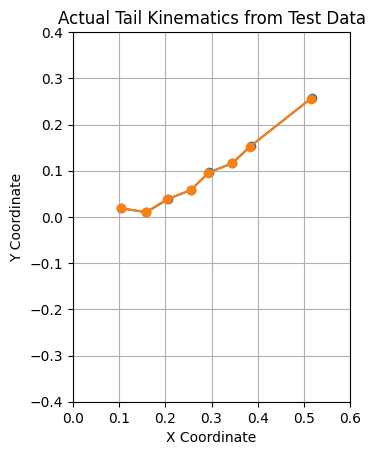

In [12]:
# Visualize random test sample prediction
import matplotlib.pyplot as plt
import random
random_index = random.randint(0, test_dataset_input.shape[0] - 1)
print(pred.shape)
print(test_dataset_input.shape)
print(random_index)
plt.figure()
plot_tail(pred[random_index].cpu().detach().numpy(), title="Predicted Tail Kinematics from Test Data")
plot_tail(test_dataset_output[random_index].cpu().detach().numpy(), title="Actual Tail Kinematics from Test Data")    
plt.grid(True)
plt.show()

In [37]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {total_params}")

Number of parameters: 366


In [40]:
# Calculate prediction time
import time
model.eval()
data = torch.randn((1,8,1), dtype=torch.float64).to(device)
start_time = time.time()
pred = model(data)
end_time = time.time()
print(f"Prediction time for one sample: {end_time - start_time:1.5E} seconds")




Prediction time for one sample: 3.25823E-03 seconds
